## Exploring Value at Risk

Description: For this project we're interested in exploring how volatility affects the leveraging/weighting of a portfolio. To do this, we'll explore a simple derivation of the VaR formula assuming deterministic volatility, followed by exploring the affects of stochastic volatility in comparison.

### The Scenario:

A hedge fund has £100mil. AUM and employs a Head of Risk to ensure that the firm avoids being overleveraged in its positions. The Head of Risk is told that they will lose their job if the firm loses more than £10mil in a single trading day. For the purpose of this analysis, we will randomly simulate firms positions as long/short via a random walk, and equally will assume that the volatility of return rates is deterministic and normally distributed. We therefore have the following:

$AUM_{t=0}$ = £100mil  
$X_{t}$ = dollar position size (long/short)  
$r_{t}$ = daily stock return, where $r$ ~ $N(0,\sigma^{2})$

Daily PnL of the position is:  
$PnL = X*r_{t}$

Since $r$ is normal,  
$PnL$ ~ $N(0,X^{2}\sigma^{2})$

Head of Risk is fired if daily loss exceeds £10mil, i.e.:  
$PnL$ $\leq$ -£10mil

#### Step 1: Standardize the distribution

$Z = \frac{PnL}{X\sigma} = N(0,1)$

So,

$P(PnL \leq -10mil) = P (Z \leq \frac{-10M}{X\sigma})$

#### Step 2: Impose a risk tolerance

Let the acceptable probability of getting fired be $\alpha$.

$P(PnL \leq -10mil) = \alpha$

Using the standard normal quantile $z_{\alpha}$:

$\frac{-10M}{X\sigma} = z_{\alpha}$ 

Solve for $X$:

$X = \frac{10M}{|z_{\alpha}|\sigma}$

#### Step 3: Final Risk Rule

The maximum allowable position size is:

$X_{max} = \frac{10M}{|z_{\alpha}|\sigma}$

### The Basic Parameters:

We will now simulate a firm taking a random walk position with upper and lower boundaries of $|X_{max}|$ and simulate daily returns in accordance with $r$ ~ $N(0,\sigma^{2})$, calculating the respective daily $PnL$.

In [28]:
# Import libraries 
import math 
import numpy as np 
import scipy
import matplotlib.pyplot as plt

In [27]:
# Set & Calculate Parameters 
T = 100 #days 
PnL_limit = 10000000 #£mil
Confidence_Lvl = 0.95
z = scipy.stats.norm.ppf(Confidence_Lvl) 
sigma = 0.125 #12.5% volatility 
X_max = PnL_limit / (abs(z))*sigma 

print(f"Details: \n Max Loss: £{PnL_limit/1000000}mil, \n Confidence Lvl: {Confidence_Lvl*100}%, \n Volatility: {sigma}, \n Maximum Dollar Position: £{X_max/1000:.0f}k")

Details: 
 Max Loss: £10.0mil, 
 Confidence Lvl: 95.0%, 
 Volatility: 0.125, 
 Maximum Dollar Position: £760k


### Interpretation:

Value at Risk constraint becomes:  
$VaR_{\alpha} = |z_{\alpha}|\sigma X$

Risk manager requires:  
$VaR_{\alpha} \leq £10mil$

So the position is automatically reduced whenever:  
$X \le \frac{£10mil}{|z_{\alpha}|\sigma}$

### Simple Summary/Rule:

Reduce exposure inversely with volatility so that the daily VaR never exceeds $£10mil$. E.g.:  

Position size, $X \propto \frac{1}{\sigma}$

### Simulating Portfolio Evolution:  

We're now interested in simulating the evolution of a portfolio under the above VaR constraints. To do this, we'll create a random walk net dollar value position for the firm and reduce the position where it hits the VaR constraint. The returns on the portfolio will be generated by multiplying the net postion against the net returns simulated through a normal distribution (Wiener Process). This will assume constaint volatility. We're interest to see if the Head of Risk get's fired!

In [84]:
# Create the random walk net dollar position
def net_position_walk(T, sigma=sigma, VaRc=X_max):

    position = np.zeros(T) 

    for t in range(1, T):
        step = np.random.normal(0, sigma) * VaRc
        position[t] = position[t-1] + step 
        if abs(position[t]) > VaRc:
            position[t] = np.sign(position[t]) * VaRc 
    
    return position 

# Create the random returns according to a normal distribution
def net_daily_returns(T, sigma=sigma): 

    net_returns = np.array([np.random.normal(0,1) for _ in range(T)])

    return net_returns 

T = 1000 
X_net = net_position_walk(T)
r_net = net_daily_returns(T)

Net Position Details: 
 Mean Position, μ: £-378075 
 Variance, σ^2: 92455338707 
 Standard Deviation, σ: 304065


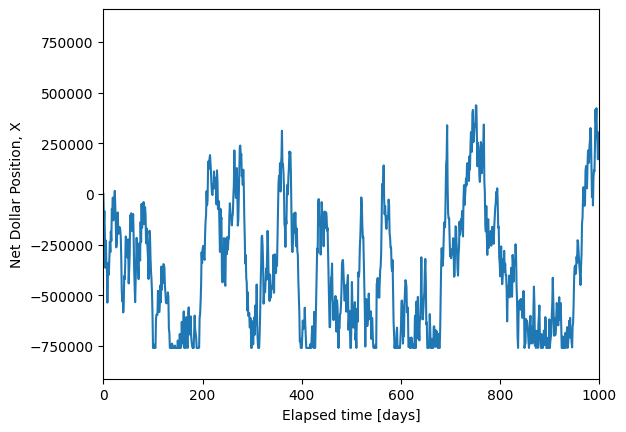

In [85]:
# Analyse the walk 
net_pos_mean = X_net.mean() 
net_pos_var = X_net.var() 
net_pos_std = math.sqrt(net_pos_var) 
print(f"Net Position Details: \n Mean Position, μ: £{net_pos_mean:.0f} \n Variance, σ^2: {net_pos_var:.0f} \n Standard Deviation, σ: {net_pos_std:.0f}") 

# Plot the results 
plt.plot(X_net) 
plt.xlabel("Elapsed time [days]") 
plt.xlim(0, T)
plt.ylabel("Net Dollar Position, X")
plt.ylim(-X_max*1.2, X_max*1.2)
plt.show() 

Net Return Details: 
 Mean, μ: £-0.050 
 Variance, σ^2: 1.006 
 Standard Deviation, σ: 1.003


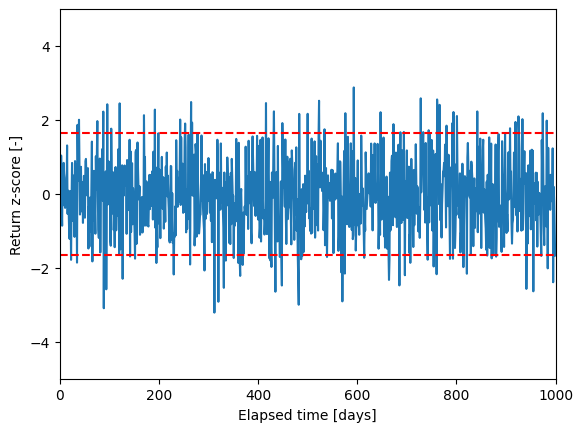

In [89]:
# Analyse the returns
r_net_mean = r_net.mean() 
r_net_var = r_net.var() 
r_net_std = math.sqrt(r_net_var) 
print(f"Net Return Details: \n Mean, μ: £{r_net_mean:.3f} \n Variance, σ^2: {r_net_var:.3f} \n Standard Deviation, σ: {r_net_std:.3f}") 

# Plot the results 
plt.plot(r_net) 
plt.plot([0, T], [z, z], 'r--')
plt.plot([0, T], [-z, -z], 'r--')
plt.xlabel("Elapsed time [days]") 
plt.xlim(0, T)
plt.ylabel("Return z-score [-]")
plt.ylim(-5, 5)
plt.show() 